In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('train.csv')

In [8]:
df

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,29,services,single,secondary,no,1282,no,yes,unknown,4,jul,1006,2,-1,0,unknown,1
749996,749996,69,retired,divorced,tertiary,no,631,no,no,cellular,19,aug,87,1,-1,0,unknown,0
749997,749997,50,blue-collar,married,secondary,no,217,yes,no,cellular,17,apr,113,1,-1,0,unknown,0
749998,749998,32,technician,married,secondary,no,-274,no,no,cellular,26,aug,108,6,-1,0,unknown,0


In [9]:
df.set_index('id', inplace = True)
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,29,services,single,secondary,no,1282,no,yes,unknown,4,jul,1006,2,-1,0,unknown,1
749996,69,retired,divorced,tertiary,no,631,no,no,cellular,19,aug,87,1,-1,0,unknown,0
749997,50,blue-collar,married,secondary,no,217,yes,no,cellular,17,apr,113,1,-1,0,unknown,0


In [15]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   age        750000 non-null  int64 
 1   job        750000 non-null  object
 2   marital    750000 non-null  object
 3   education  750000 non-null  object
 4   default    750000 non-null  object
 5   balance    750000 non-null  int64 
 6   housing    750000 non-null  object
 7   loan       750000 non-null  object
 8   contact    750000 non-null  object
 9   day        750000 non-null  int64 
 10  month      750000 non-null  object
 11  duration   750000 non-null  int64 
 12  campaign   750000 non-null  int64 
 13  pdays      750000 non-null  int64 
 14  previous   750000 non-null  int64 
 15  poutcome   750000 non-null  object
 16  y          750000 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 103.0+ MB


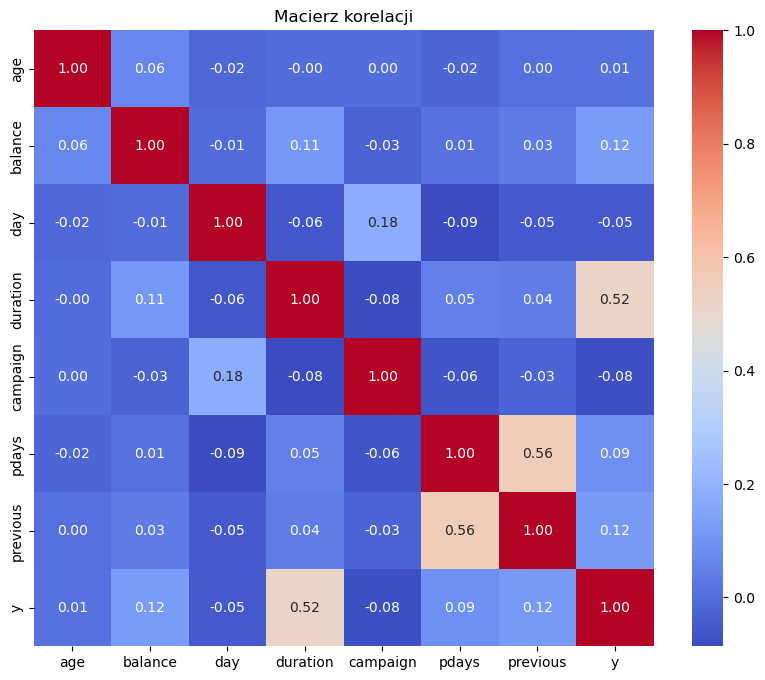

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Macierz korelacji")
plt.show()

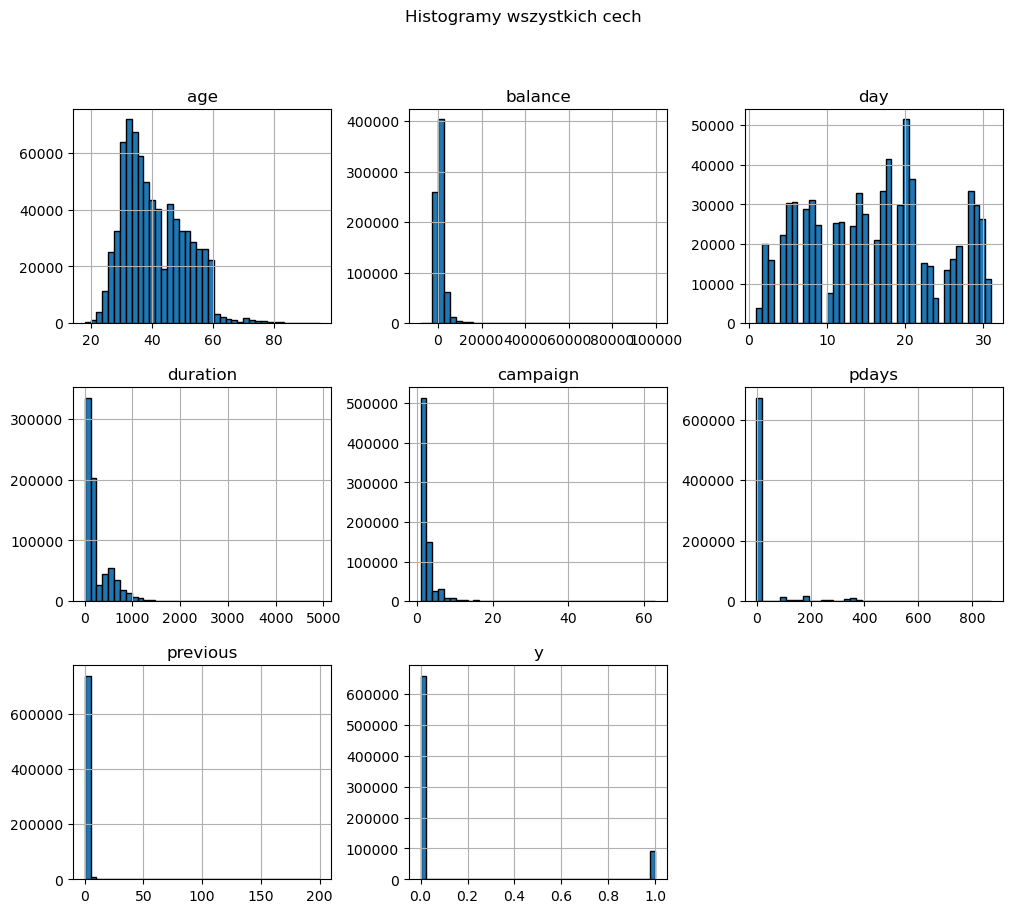

In [18]:
df.hist(figsize=(12,10), bins=40, edgecolor='black')
plt.suptitle("Histogramy wszystkich cech")
plt.show()

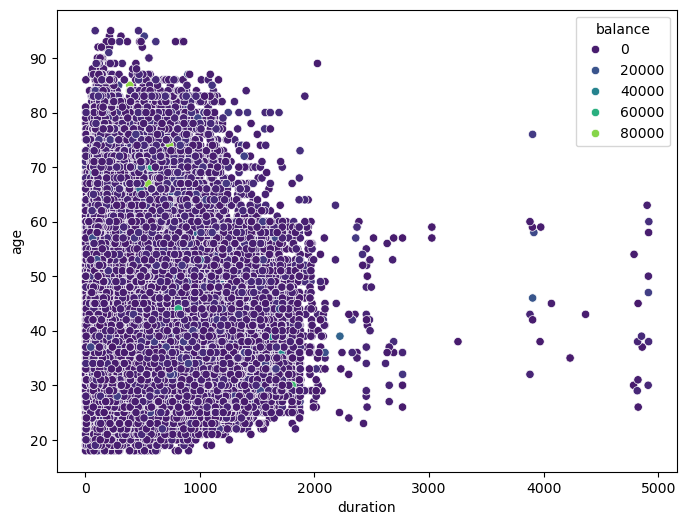

In [25]:
# 6. Scatterplot dla wybranych cech (np. Energy vs MoodScore)
plt.figure(figsize=(8,6))
sns.scatterplot(x="duration", y="age", data=df, hue="balance", palette="viridis")
#plt.title("Energy vs MoodScore z LivePerformanceLikelihood jako kolor")
plt.show()

In [26]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNum cols ({len(num_cols)}):", num_cols)
print(f"Cat cols ({len(cat_cols)}):", cat_cols)


Num cols (8): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y']
Cat cols (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


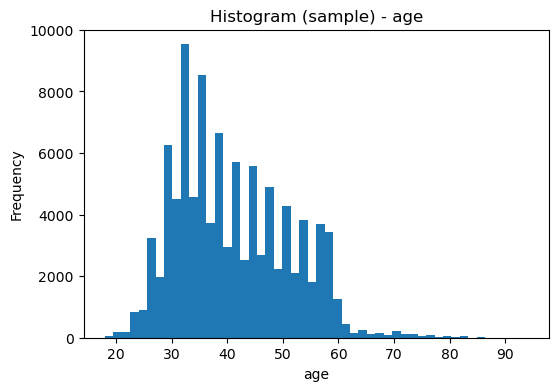

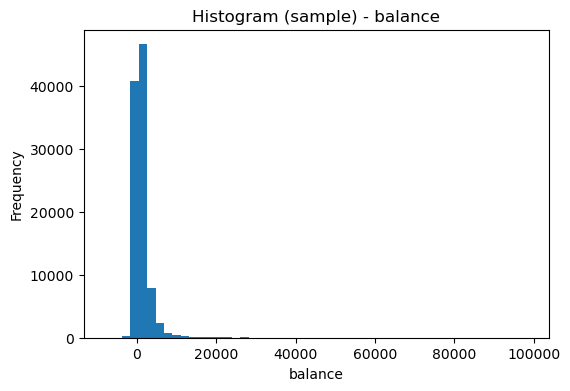

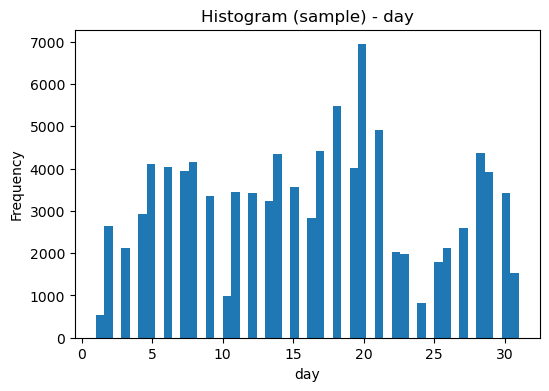

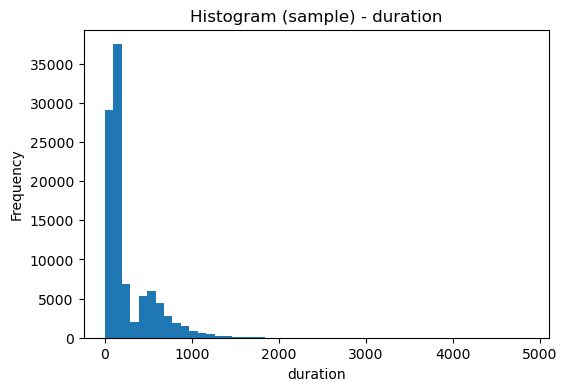

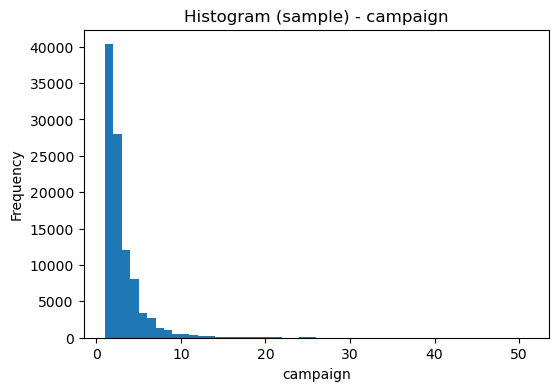

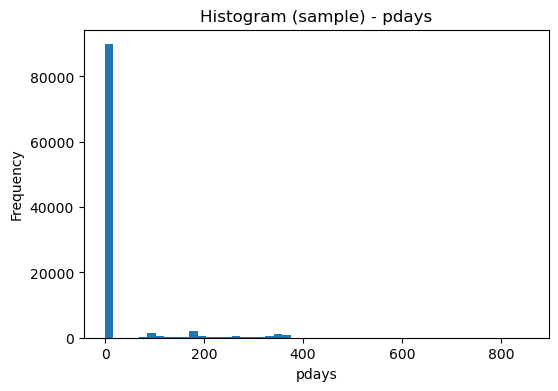

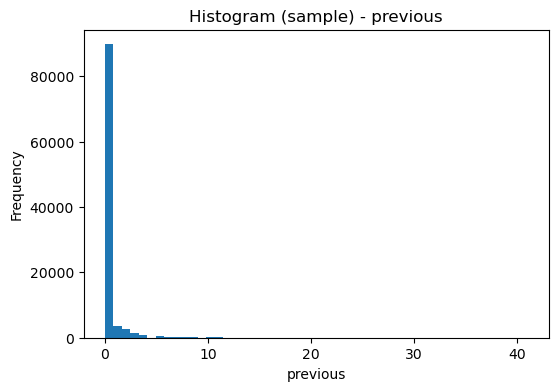

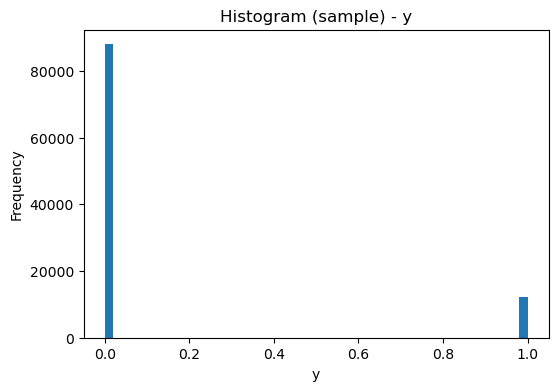

In [28]:
SAMPLE_N = 100_000      # ile wierszy do próbkowania do wykresów
TOP_K = 20              # ile top kategorii pokazywać
sample = df.sample(n=min(SAMPLE_N, len(df)), random_state=42)
for c in num_cols:
    plt.figure(figsize=(6,4))
    sample[c].plot(kind="hist", bins=50)
    plt.title(f"Histogram (sample) - {c}")
    plt.xlabel(c)
    plt.show()

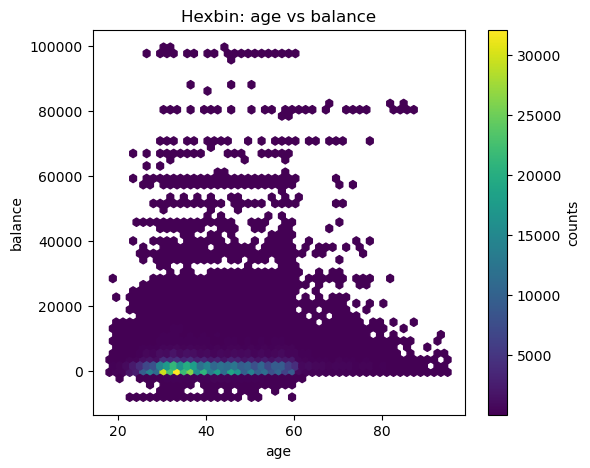

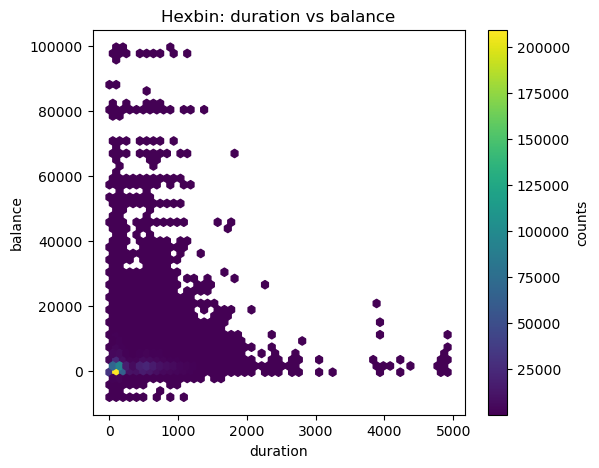

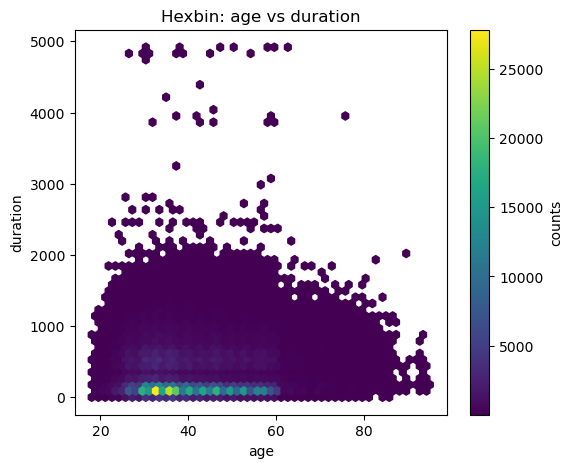

In [ ]:
pairs = [("age", "balance"), ("duration", "balance"), ("age", "duration")]
for x, y in pairs:
    if x in df.columns and y in df.columns:
        plt.figure(figsize=(6,5))
        plt.hexbin(df[x], df[y], gridsize=50, mincnt=1)
        plt.colorbar(label="counts")
        plt.xlabel(x); plt.ylabel(y)
        plt.title(f"Hexbin: {x} vs {y}")
        plt.show()


--- ROZKŁAD TARGETU y ---
y
0    0.879349
1    0.120651
Name: proportion, dtype: float64


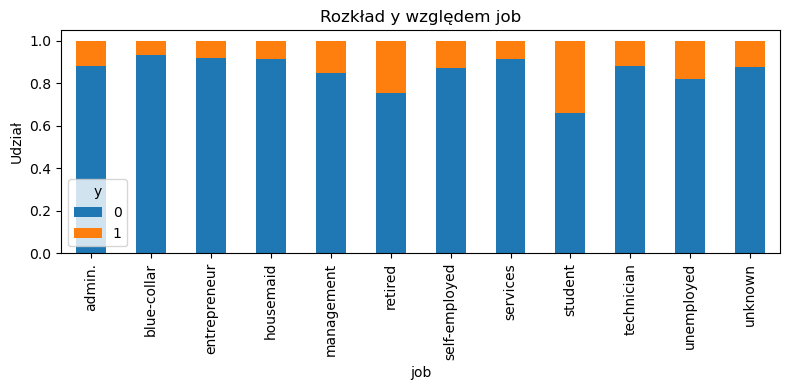

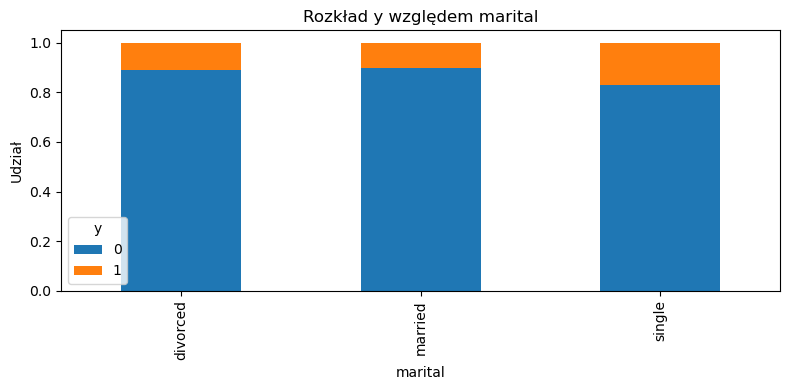

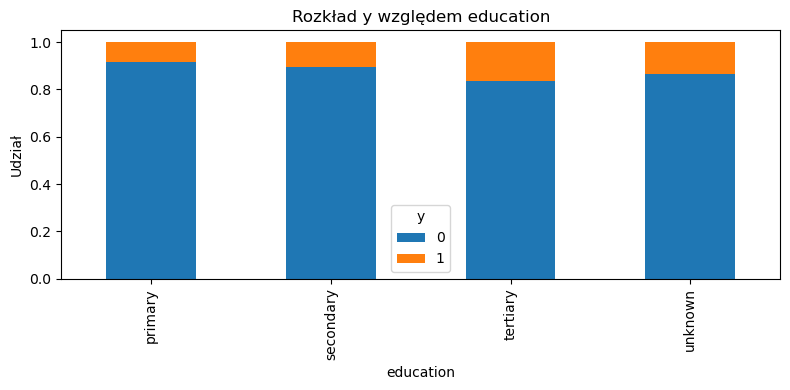

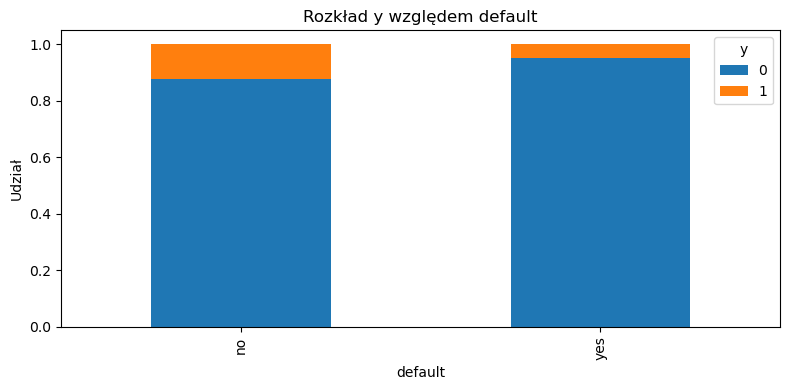

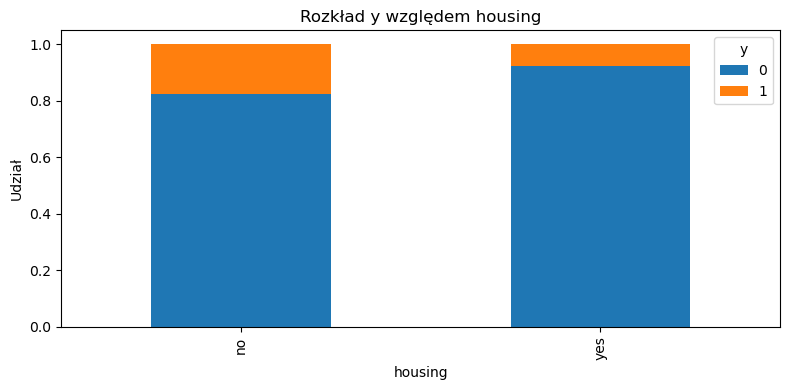

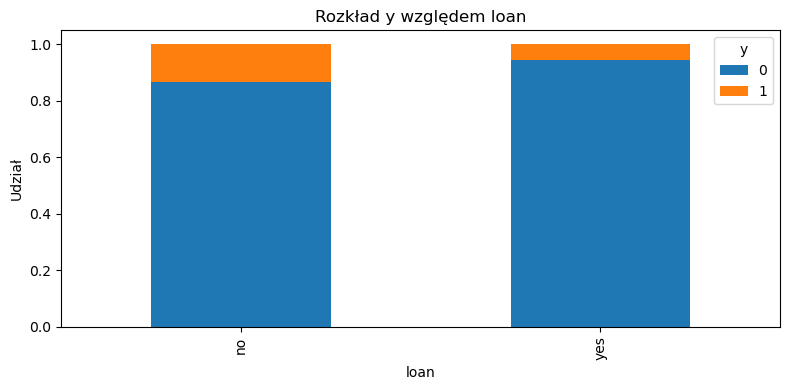

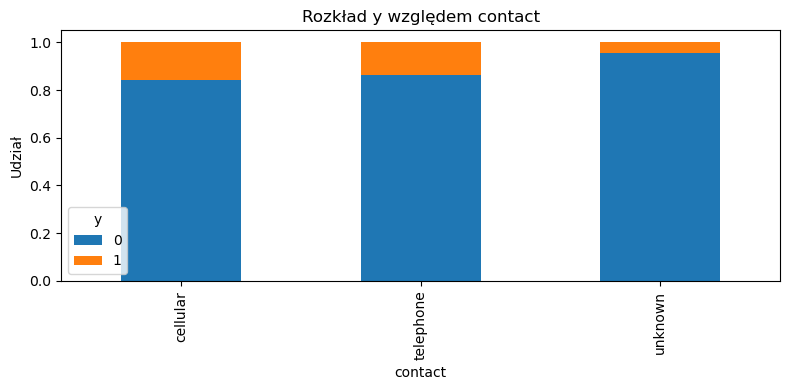

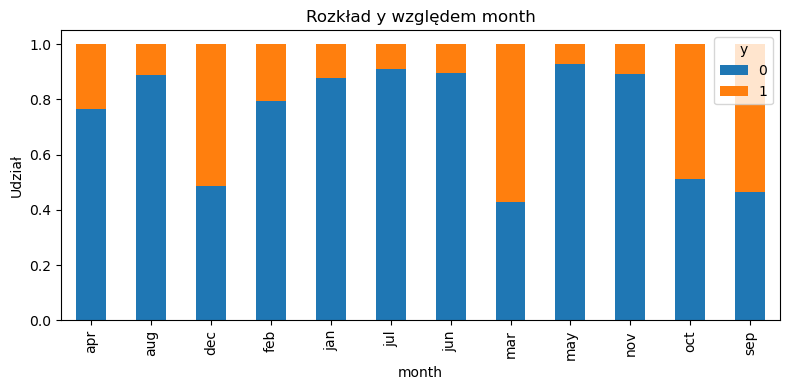

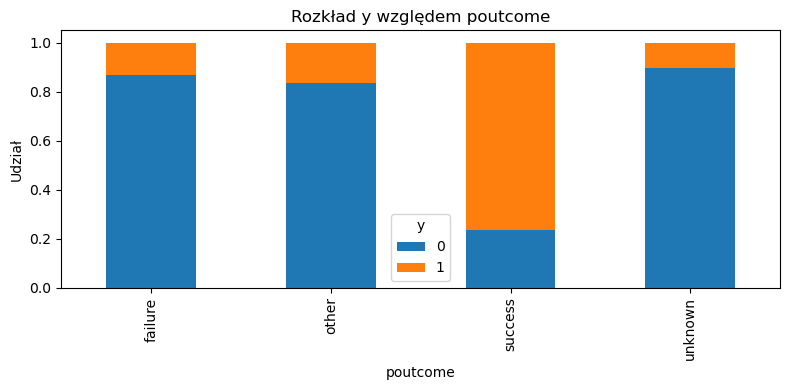

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\137079576.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(binned)["y"].value_counts(normalize=True).unstack(fill_value=0)


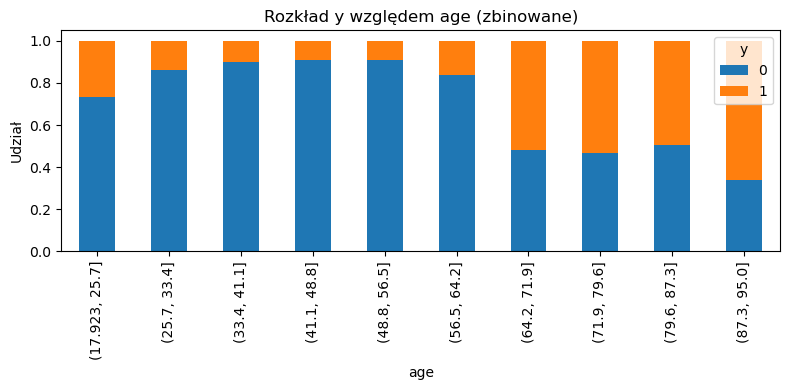

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\137079576.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(binned)["y"].value_counts(normalize=True).unstack(fill_value=0)


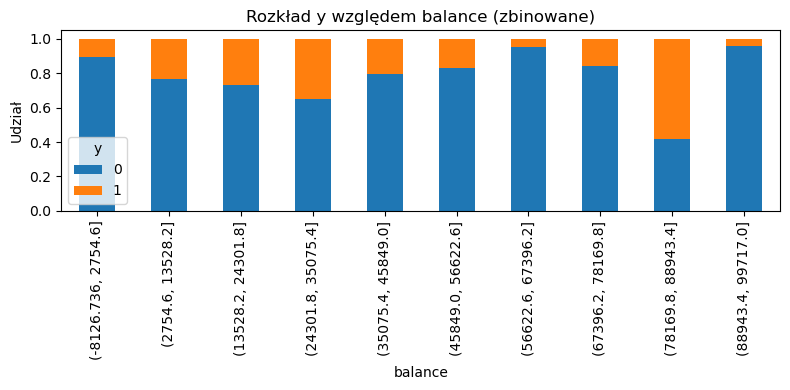

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\137079576.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(binned)["y"].value_counts(normalize=True).unstack(fill_value=0)


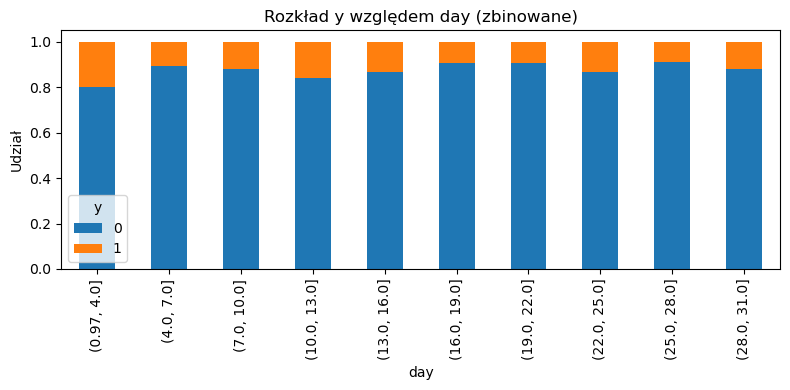

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\137079576.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(binned)["y"].value_counts(normalize=True).unstack(fill_value=0)


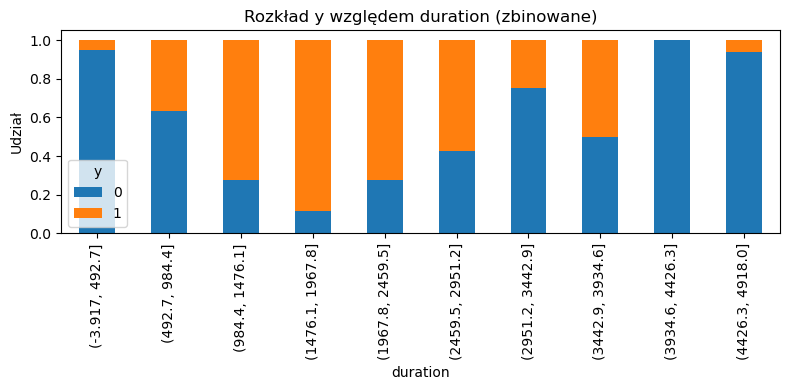

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\137079576.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(binned)["y"].value_counts(normalize=True).unstack(fill_value=0)


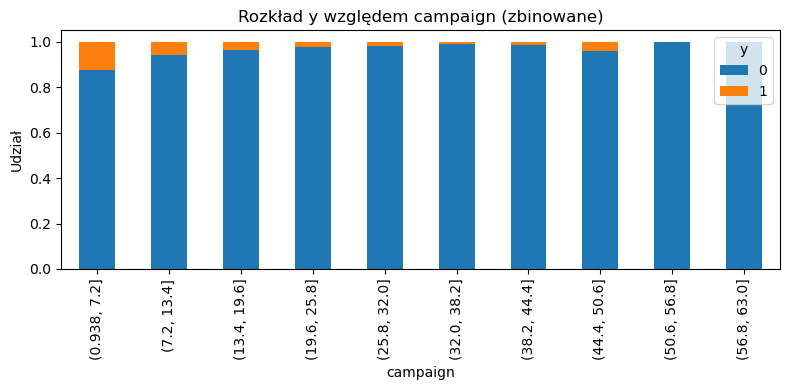

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\137079576.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(binned)["y"].value_counts(normalize=True).unstack(fill_value=0)


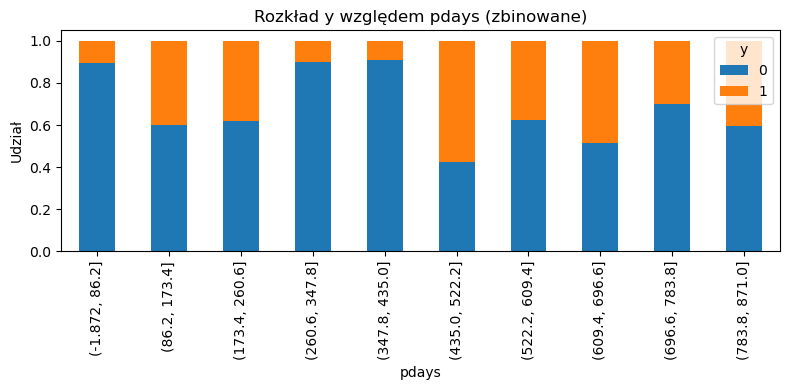

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\137079576.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(binned)["y"].value_counts(normalize=True).unstack(fill_value=0)


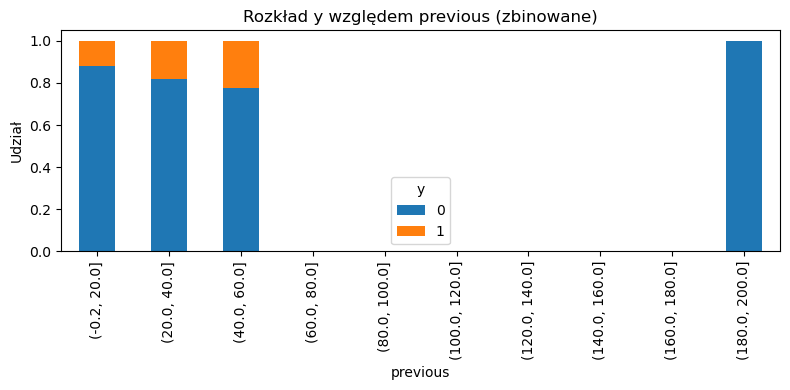

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\137079576.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(binned)["y"].value_counts(normalize=True).unstack(fill_value=0)


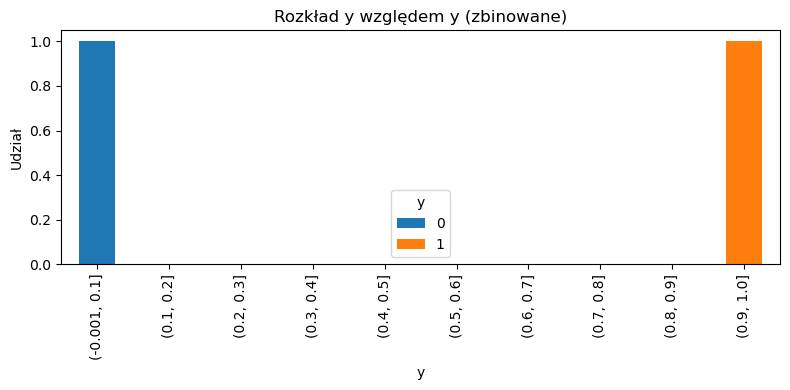

In [32]:
if "y" in df.columns:
    print("\n--- ROZKŁAD TARGETU y ---")
    print(df["y"].value_counts(normalize=True))

    # kategorie
    for c in cat_cols:
        if c == "y":
            continue
        agg = df.groupby(c)["y"].value_counts(normalize=True).unstack(fill_value=0)

        # wykres kolumnowy
        agg.plot(kind="bar", stacked=True, figsize=(8,4))
        plt.title(f"Rozkład y względem {c}")
        plt.ylabel("Udział")
        plt.xlabel(c)
        plt.legend(title="y")
        plt.tight_layout()
        plt.show()

    # numeryczne
    for c in num_cols:
        try:
            binned = pd.cut(df[c], bins=10)
            agg = df.groupby(binned)["y"].value_counts(normalize=True).unstack(fill_value=0)

            # wykres kolumnowy
            agg.plot(kind="bar", stacked=True, figsize=(8,4))
            plt.title(f"Rozkład y względem {c} (zbinowane)")
            plt.ylabel("Udział")
            plt.xlabel(c)
            plt.legend(title="y")
            plt.tight_layout()
            plt.show()
        except Exception:
            pass


In [31]:
print("\n--- OUTLIERS (IQR) ---")
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < low) | (df[c] > high)).sum()
    print(f"{c}: outliers={n_out}, low={low:.2f}, high={high:.2f}")


--- OUTLIERS (IQR) ---
age: outliers=4903, low=10.50, high=70.50
balance: outliers=57745, low=-2085.00, high=3475.00
day: outliers=0, low=-9.00, high=39.00
duration: outliers=46118, low=-314.00, high=766.00
campaign: outliers=40686, low=-2.00, high=6.00
pdays: outliers=77566, low=-1.00, high=-1.00
previous: outliers=77569, low=0.00, high=0.00
y: outliers=90488, low=0.00, high=0.00


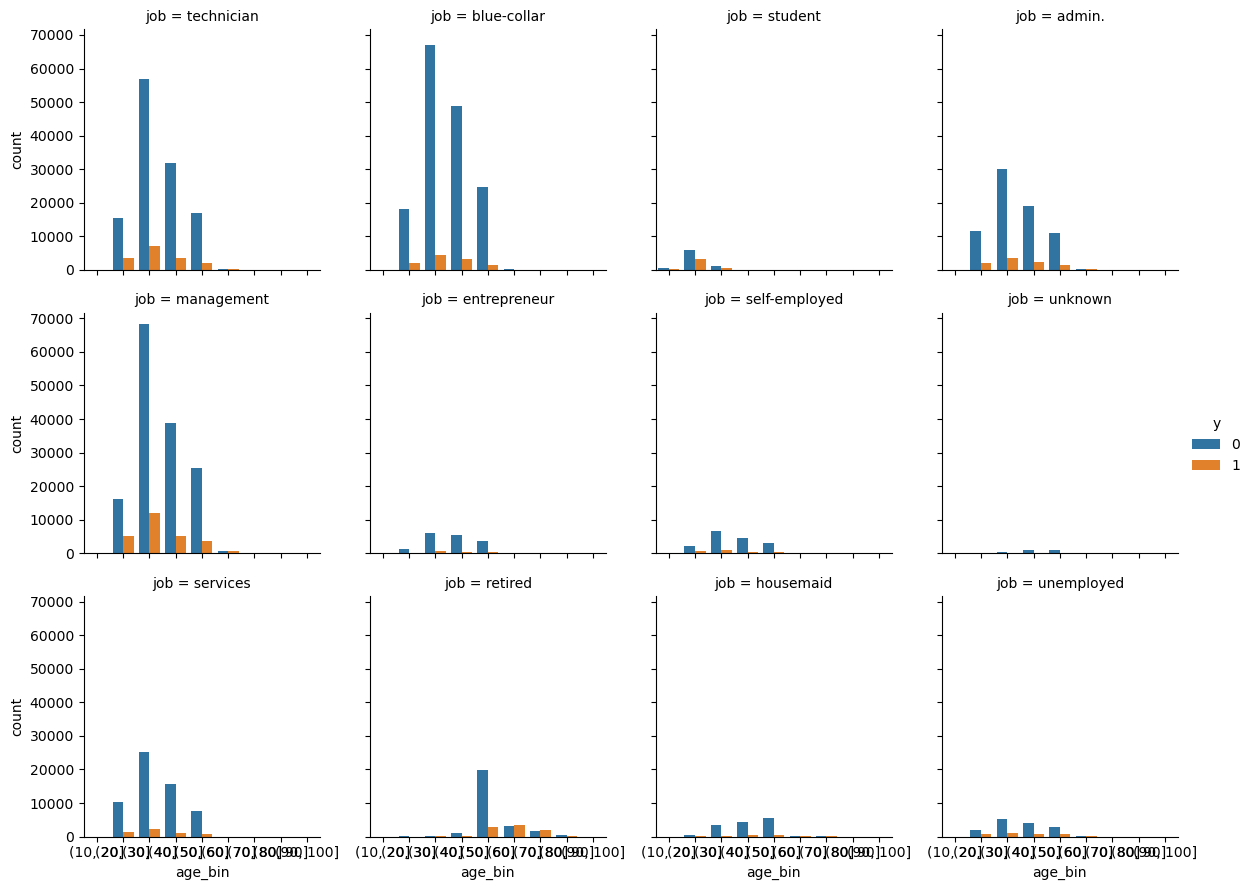

In [35]:

# binowanie wieku co 10 lat
df["age_bin"] = pd.cut(df["age"], bins=range(10, 101, 10))  # np. 10–20, 20–30, ...

sns.catplot(
    data=df, x="age_bin", hue="y", col="job",
    kind="count", col_wrap=4, height=3
)
plt.show()


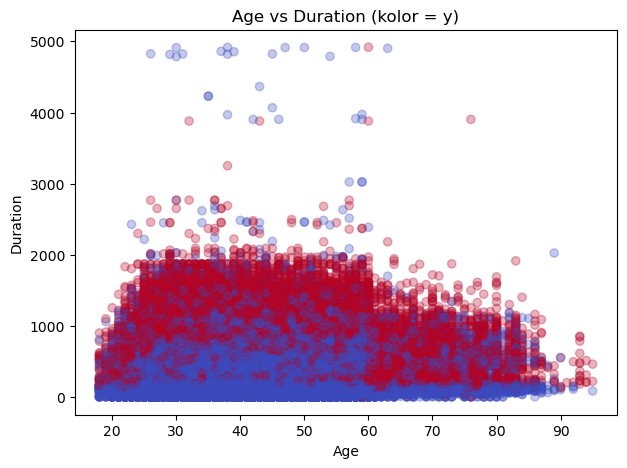

In [37]:
plt.figure(figsize=(7,5))
plt.scatter(
    df["age"], df["duration"],
    c=df["y"].astype("category").cat.codes, alpha=0.3, cmap="coolwarm"
)
plt.xlabel("Age")
plt.ylabel("Duration")
plt.title("Age vs Duration (kolor = y)")
plt.show()


C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\223462022.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


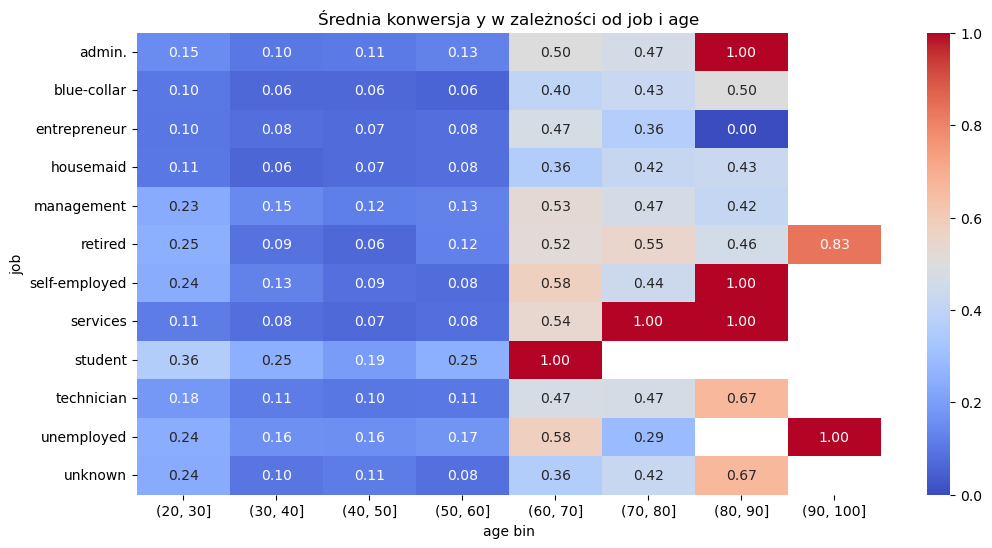

In [40]:
# np. bins co 10 lat
age_bins = pd.cut(df["age"], bins=range(20, 101, 10))  # 20-30, 30-40, ...

pivot = df.pivot_table(
    index="job",
    columns=age_bins,
    values="y",     # już binarne 0/1
    aggfunc="mean"  # średnia = udział 1
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Średnia konwersja y w zależności od job i age")
plt.ylabel("job")
plt.xlabel("age bin")
plt.show()


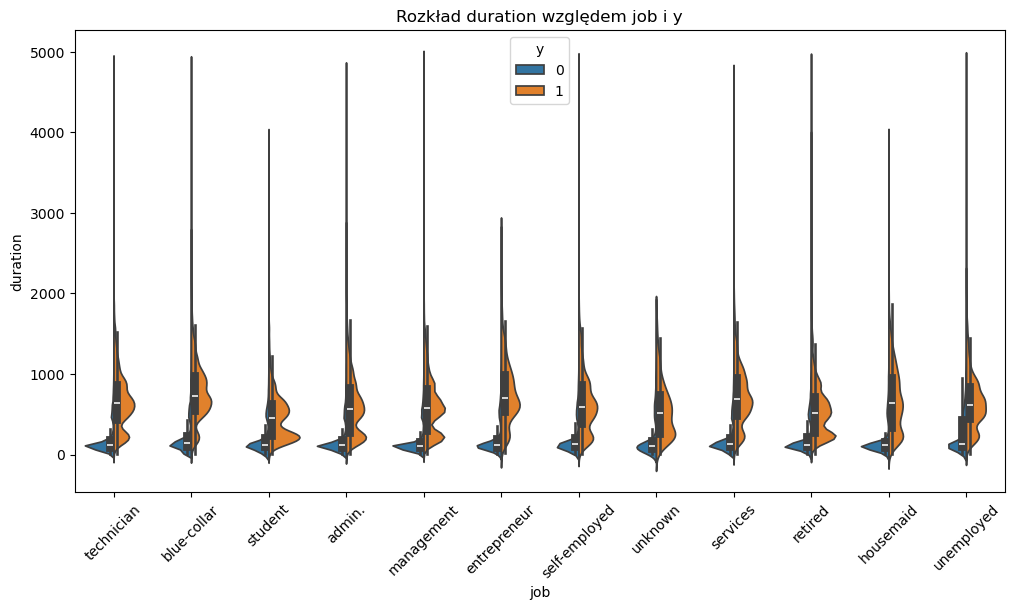

In [41]:
plt.figure(figsize=(12,6))
sns.violinplot(data=df, x="job", y="duration", hue="y", split=True)
plt.xticks(rotation=45)
plt.title("Rozkład duration względem job i y")
plt.show()

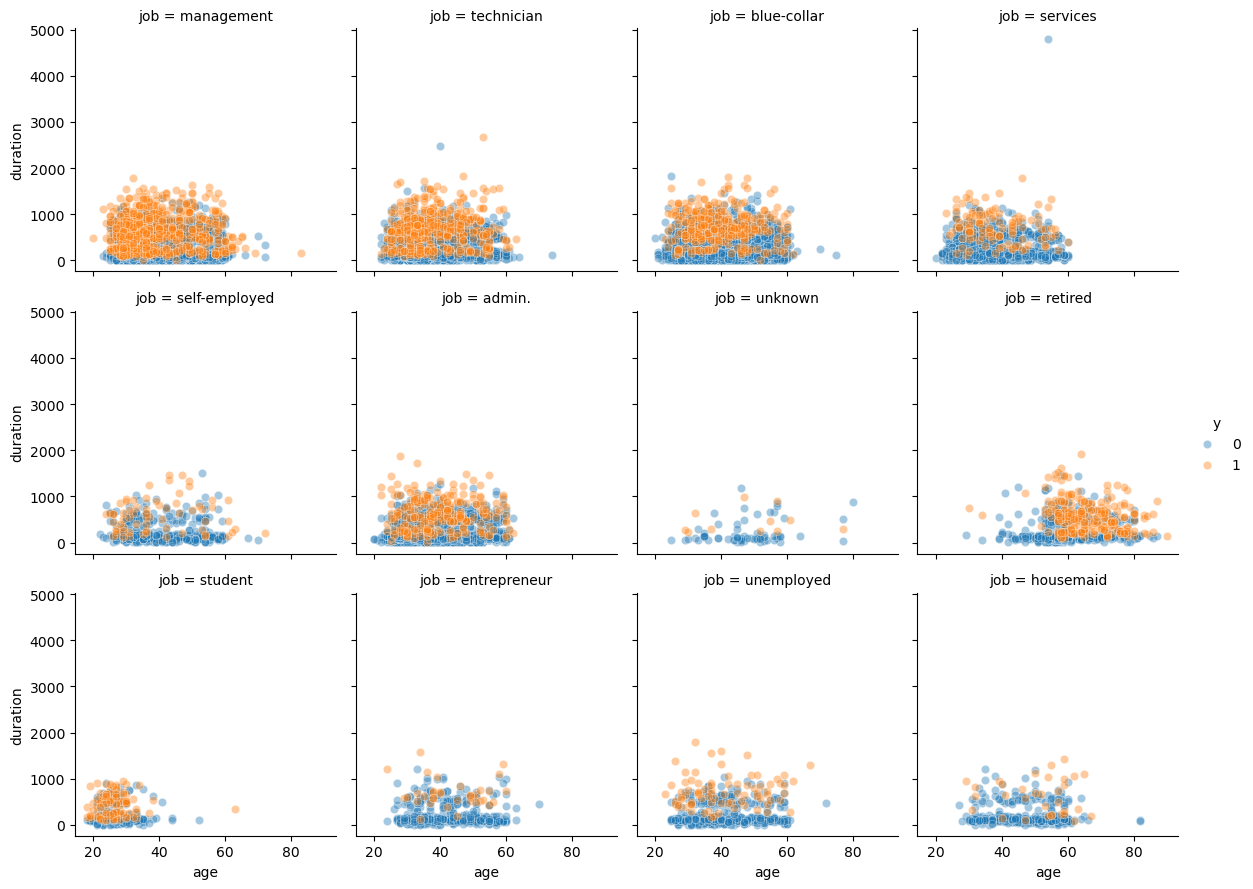

In [ ]:
g = sns.FacetGrid(df.sample(20000), col="job", col_wrap=4, height=3, hue="y")
g.map(sns.scatterplot, "age", "duration", alpha=0.4)
g.add_legend()

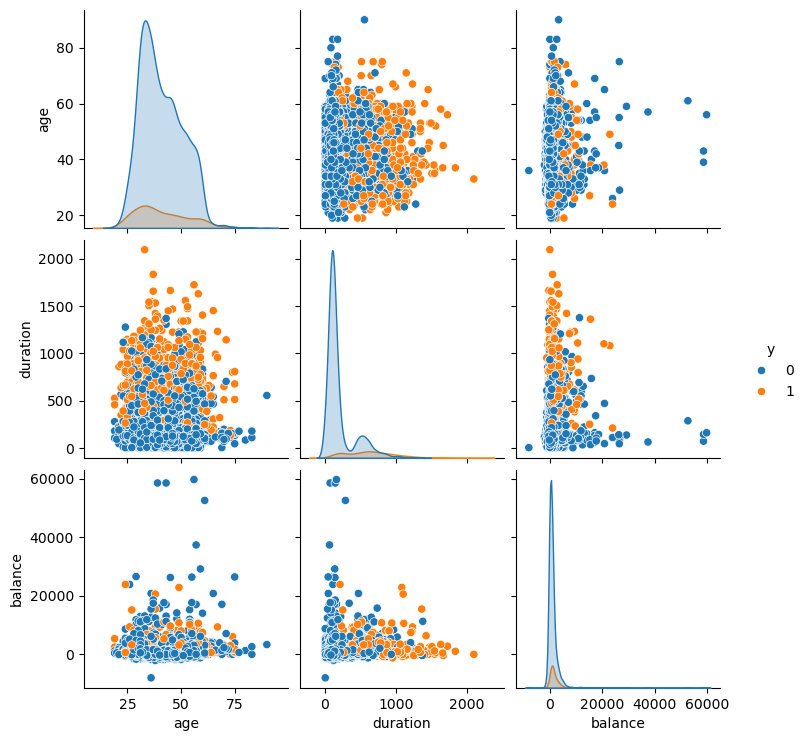

In [43]:
sample = df.sample(5000)
sns.pairplot(sample, vars=["age", "duration", "balance"], hue="y")

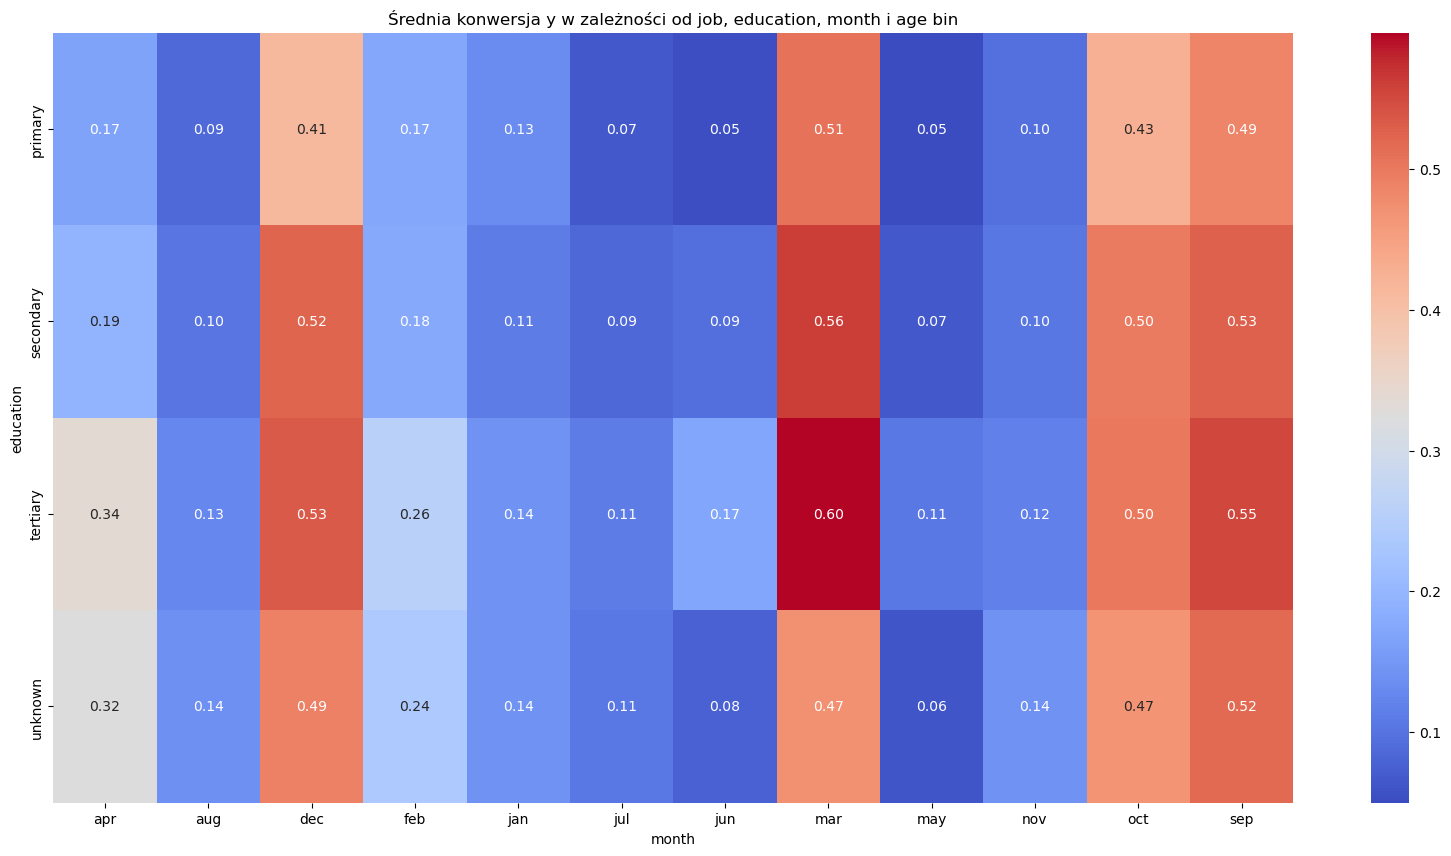

In [55]:
# Zakładam, że 'y' jest już 0/1
# Binning wieku co 10 lat
df["age_bin"] = pd.cut(df["age"], bins=range(20, 101, 10))

# Pivot table: średnia konwersja y w zależności od job, education i month w podziale na age biny
pivot = df.pivot_table(
    index=["education"],    # grupowanie po dwóch kategoriach
    columns=["month"],  # kolumny to month × age_bin
    values="y",
    aggfunc="mean"
)

# Heatmapa – uwaga, że będzie szeroka jeśli mamy dużo miesięcy i binów
plt.figure(figsize=(20,10))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Średnia konwersja y w zależności od job, education, month i age bin")
#plt.ylabel("job + education")
#plt.xlabel("month + age bin")
plt.show()

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\3842221483.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


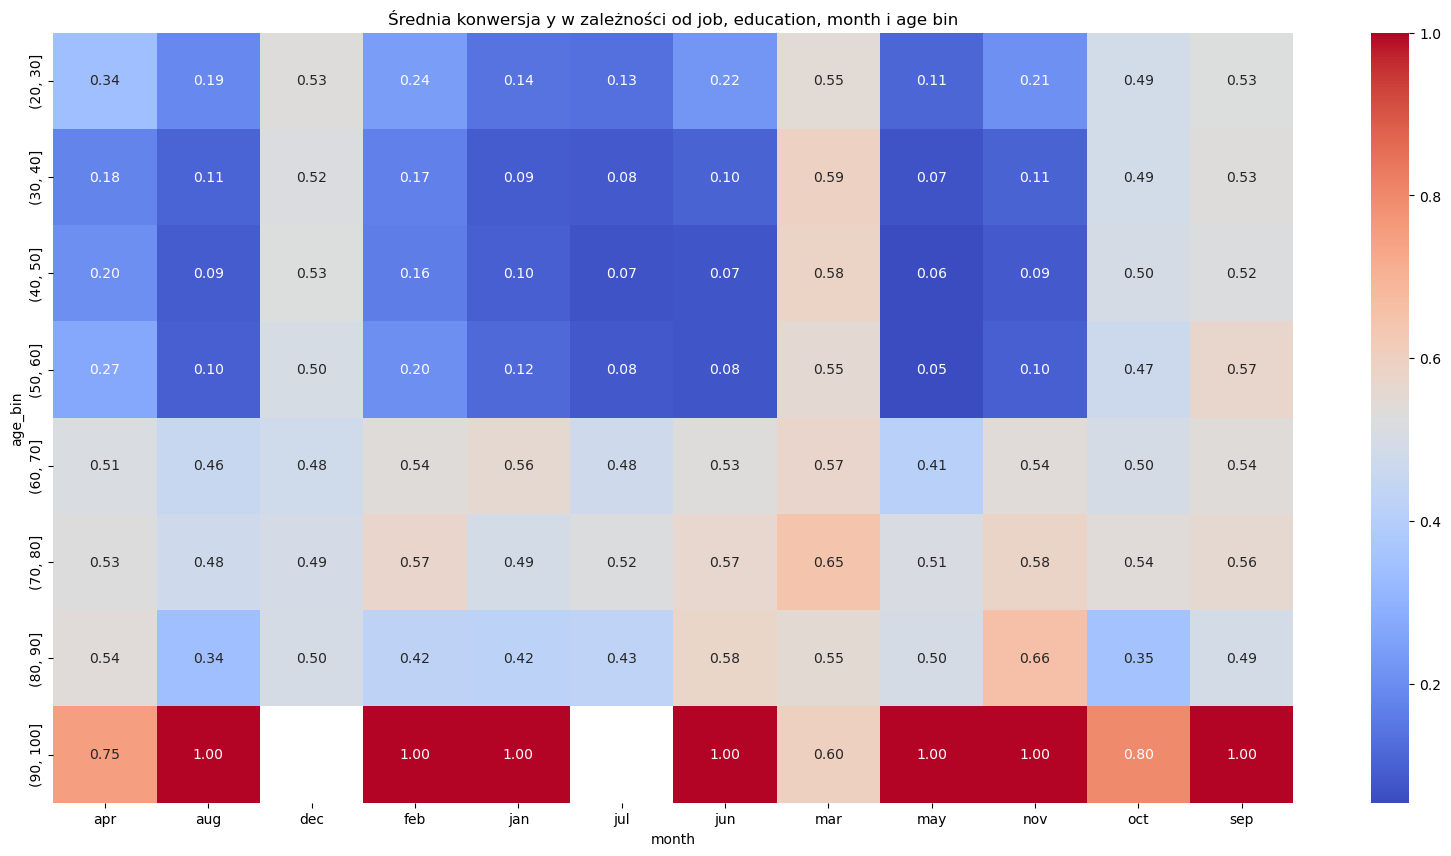

In [56]:
# Pivot table: średnia konwersja y w zależności od job, education i month w podziale na age biny
pivot = df.pivot_table(
    index=["age_bin"],    # grupowanie po dwóch kategoriach
    columns=["month"],  # kolumny to month × age_bin
    values="y",
    aggfunc="mean"
)

# Heatmapa – uwaga, że będzie szeroka jeśli mamy dużo miesięcy i binów
plt.figure(figsize=(20,10))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Średnia konwersja y w zależności od job, education, month i age bin")
plt.show()

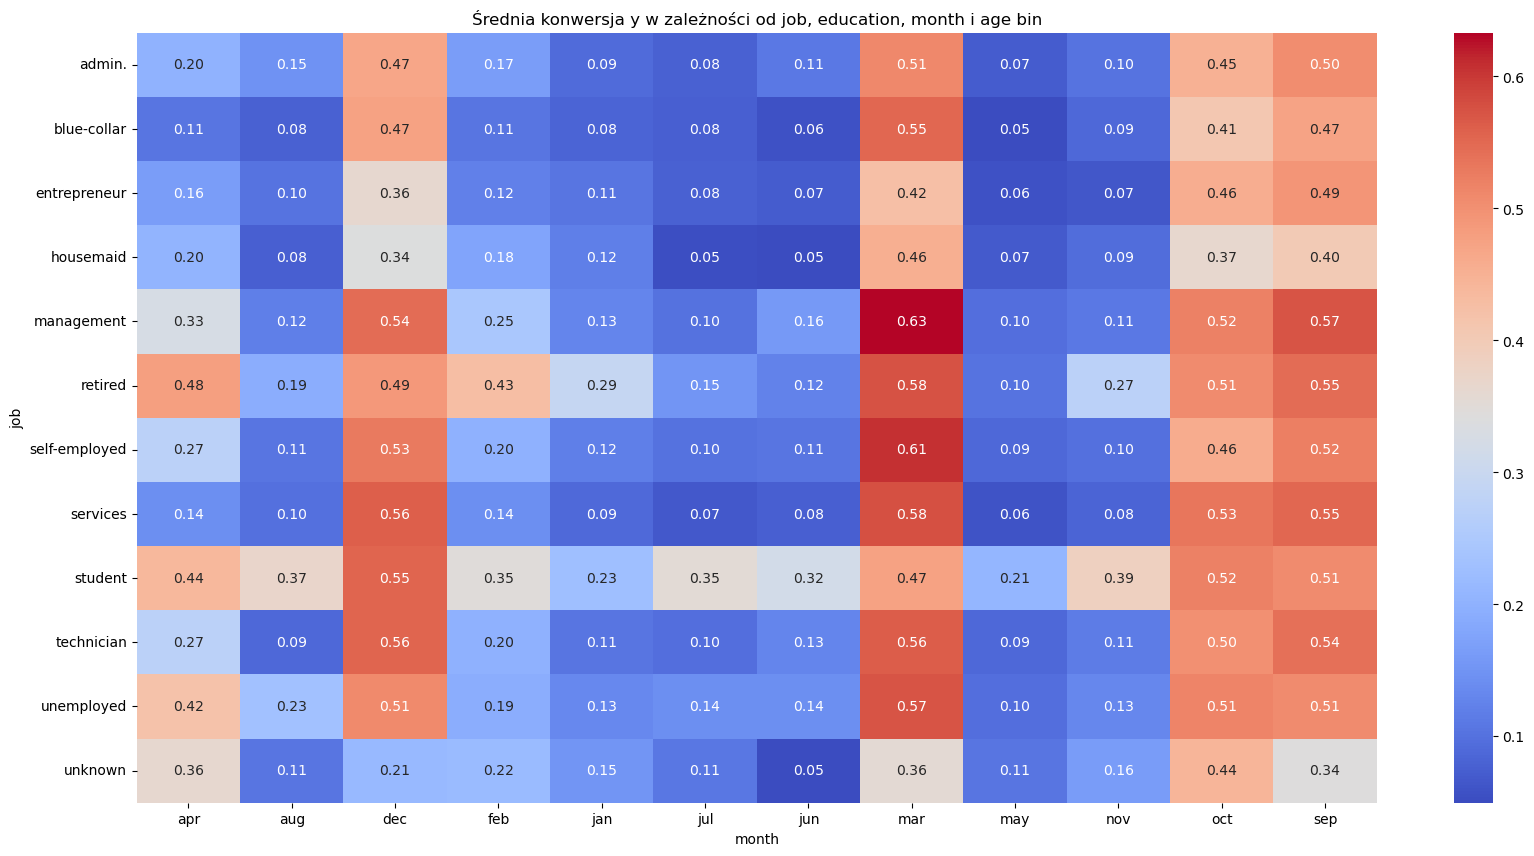

In [57]:
pivot = df.pivot_table(
    index=["job"],    # grupowanie po dwóch kategoriach
    columns=["month"],  # kolumny to month × age_bin
    values="y",
    aggfunc="mean"
)

# Heatmapa – uwaga, że będzie szeroka jeśli mamy dużo miesięcy i binów
plt.figure(figsize=(20,10))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Średnia konwersja y w zależności od job, education, month i age bin")
plt.show()

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\3880382065.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


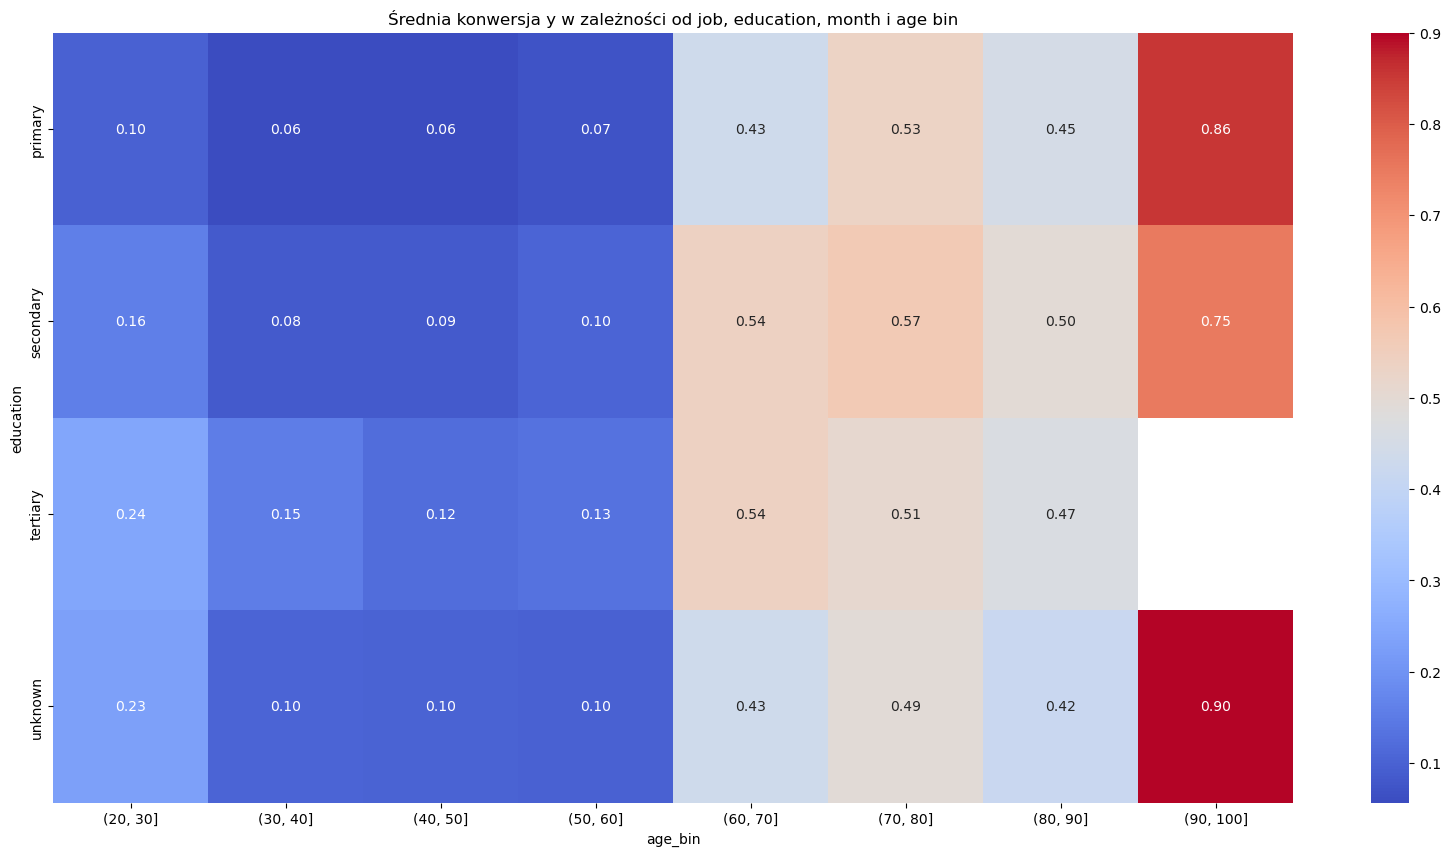

In [58]:
pivot = df.pivot_table(
    index=["education"],    # grupowanie po dwóch kategoriach
    columns=["age_bin"],  # kolumny to month × age_bin
    values="y",
    aggfunc="mean"
)

# Heatmapa – uwaga, że będzie szeroka jeśli mamy dużo miesięcy i binów
plt.figure(figsize=(20,10))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Średnia konwersja y w zależności od job, education, month i age bin")
plt.show()

C:\Users\szymo\AppData\Local\Temp\ipykernel_2612\172046405.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


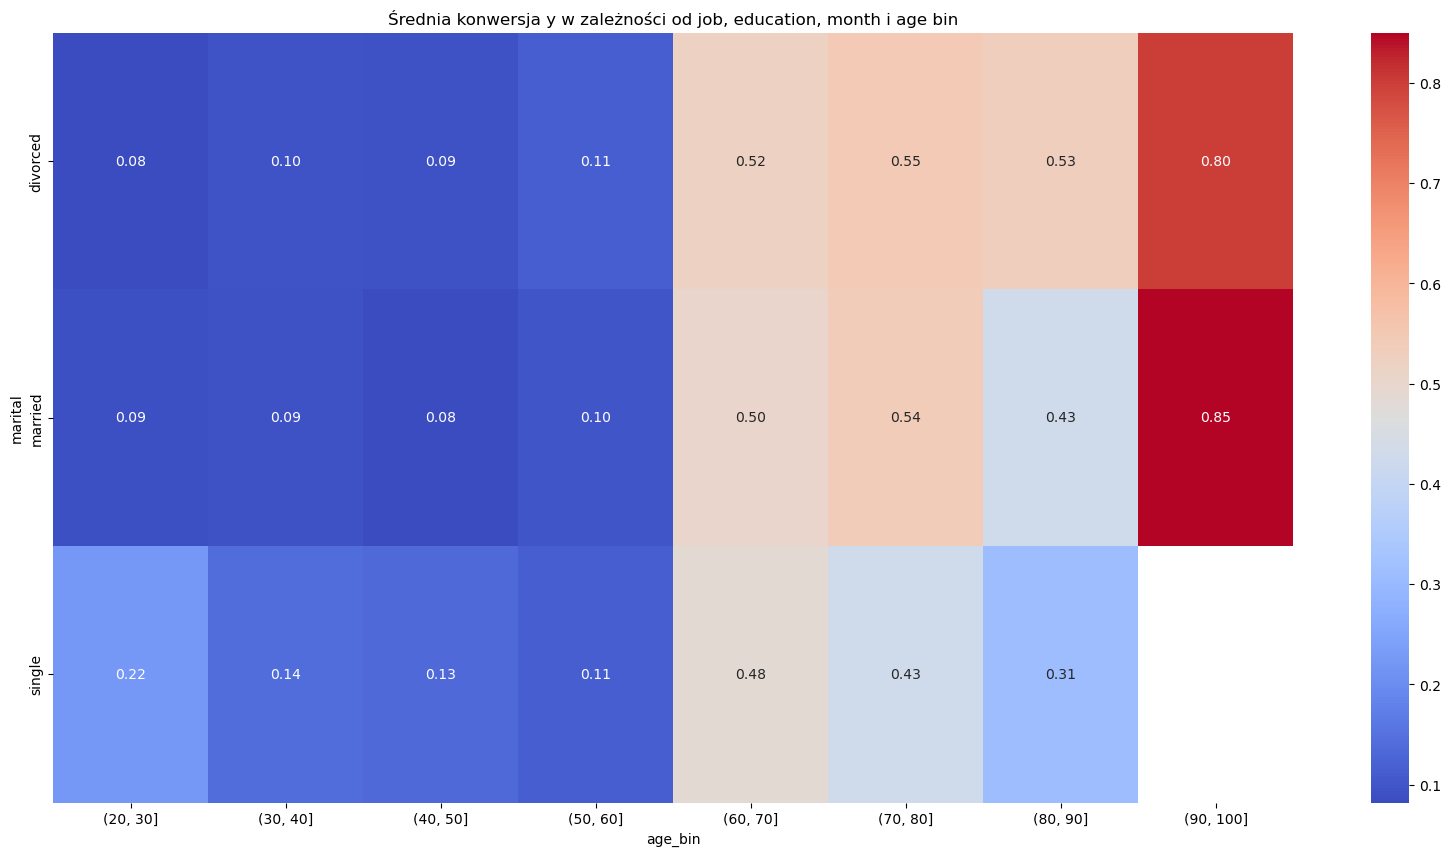

In [59]:
pivot = df.pivot_table(
    index=["marital"],    # grupowanie po dwóch kategoriach
    columns=["age_bin"],  # kolumny to month × age_bin
    values="y",
    aggfunc="mean"
)

# Heatmapa – uwaga, że będzie szeroka jeśli mamy dużo miesięcy i binów
plt.figure(figsize=(20,10))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Średnia konwersja y w zależności od job, education, month i age bin")
plt.show()